In [1]:
import pandas as pd
import numpy as np
import requests
from io import BytesIO
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


url =  "https://unipa-my.sharepoint.com/:x:/g/personal/mattia_tarantino02_you_unipa_it/IQA-0r1AndU1T43HxvIdgSngAVKON4a9IE2ZQVRP0imPRo4?download=1"
def Leggi_File_excel(url, sheet_name = 0):

    response = requests.get(url)
    response.raise_for_status()

    excel_file = BytesIO(response.content)
    df = pd.read_excel(excel_file, sheet_name = sheet_name)
    return df

def Linear_Fit(m, q, x):

    return m*x + q

def Voltage_Fit( Area, Voltage, x, epsilon_0 = 8.9e-12):

    return epsilon_0 * Area *Voltage/x
   

df = Leggi_File_excel(url,0)

#print(df)

Col_1 = "d (cm)"

Col_2 = "V"

d = df[Col_1].to_numpy()
V = df[Col_2].to_numpy()

d_0 = d[~np.isnan(d)]
d_0/=100
V_0 = V[~np.isnan(V)]

epsilon_0 = 8.9e-12
#Unità di misura in metri
"""Il Raggio Del condensatore"""
R_cond = 8.9e-2
Err_d = 5e-4
Errore_Raggio_Cond = 0.1e-3
Err_V = 0.25


"""Raggio Sfera"""
R_sph = 6.0e-2
Err_R_sph = 5e-4

Circonferenza = 2*R_sph*np.pi

#print(Circonferenza)

Area_Condensatore = (R_cond**2)*np.pi
Errore_Area_Condensatore = 2* R_cond * Errore_Raggio_Cond * np.pi
Capacita_Eletrometro = 27e-12

Distanza_Teorica = epsilon_0 * Area_Condensatore/Capacita_Eletrometro
""" Il ± si fa con 241"""
print(f"Distanza Teorica: {Distanza_Teorica}")
print(f"Area Condensatore: {Area_Condensatore} ± {Errore_Area_Condensatore}")

Distanza Teorica: 0.008202686782994602
Area Condensatore: 0.024884555409084748 ± 5.592034923389832e-05


# Grafici

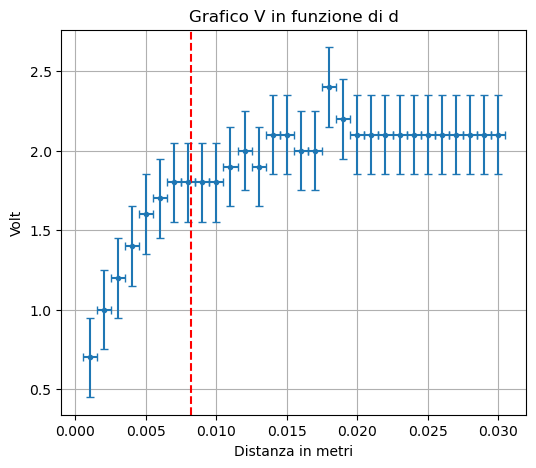

In [2]:
fig , ax = plt.subplots(figsize = (6,5))

ax.errorbar(d_0,V_0, xerr = Err_d, yerr = Err_V, fmt = ".", capsize = 3)
ax.set_xlabel("Distanza in metri")
ax.set_ylabel("Volt")
ax.grid(True)
ax.set_title("Grafico V in funzione di d")
ax.axvline(x = Distanza_Teorica, color = "red", linestyle = "--")

In [3]:

df = Leggi_File_excel(url, 1)

d = df[Col_1].to_numpy()
V = df[Col_2].to_numpy()

d_1 = d[~np.isnan(d)]
d_1/=100
V_1 = V[~np.isnan(V)]


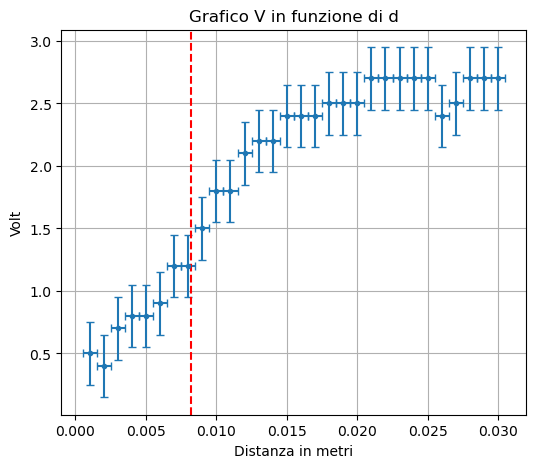

In [4]:
fig , ax = plt.subplots(figsize = (6,5))

ax.errorbar(d_1,V_1, xerr = Err_d, yerr = Err_V, fmt = ".", capsize = 3)
ax.set_xlabel("Distanza in metri")
ax.set_ylabel("Volt")
ax.grid(True)
ax.set_title("Grafico V in funzione di d")
ax.axvline(x = Distanza_Teorica, color = "red", linestyle = "--")

In [5]:
df = Leggi_File_excel(url, 2)

d = df[Col_1].to_numpy()
V = df[Col_2].to_numpy()

d_2 = d[~np.isnan(d)]
d_2/=100
V_2 = V[~np.isnan(V)]


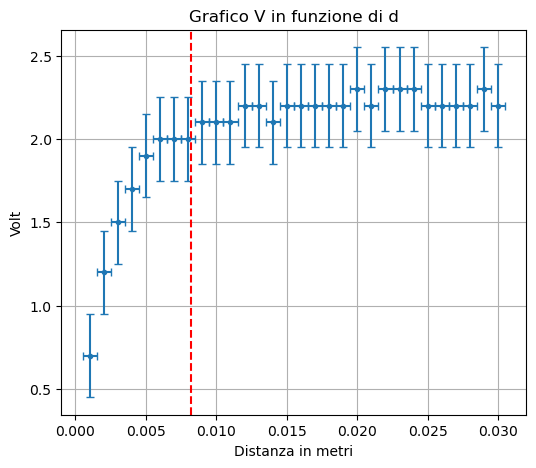

In [6]:
fig , ax = plt.subplots(figsize = (6,5))

ax.errorbar(d_2,V_2, xerr = Err_d, yerr = Err_V, fmt = ".", capsize = 3)
ax.set_xlabel("Distanza in metri")
ax.set_ylabel("Volt")
ax.grid(True)
ax.set_title("Grafico V in funzione di d")
ax.axvline(x = Distanza_Teorica, color = "red", linestyle = "--")

# Ponendo Il Voltaggio a 1000 V

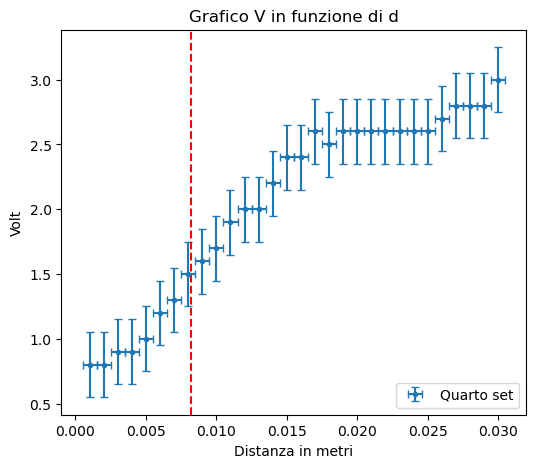

In [7]:
df = Leggi_File_excel(url, 3)

d = df[Col_1].to_numpy()
V = df[Col_2].to_numpy()

d_3 = d[~np.isnan(d)]
d_3/=100
V_3 = V[~np.isnan(V)]



fig , ax = plt.subplots(figsize = (6,5))

ax.errorbar(d_3,V_3, xerr = Err_d, yerr = Err_V, fmt = ".", capsize = 3,label = "Quarto set")
ax.set_xlabel("Distanza in metri")
ax.set_ylabel("Volt")
ax.legend()
ax.set_title("Grafico V in funzione di d")
ax.axvline(x = Distanza_Teorica, color = "red", linestyle = "--")

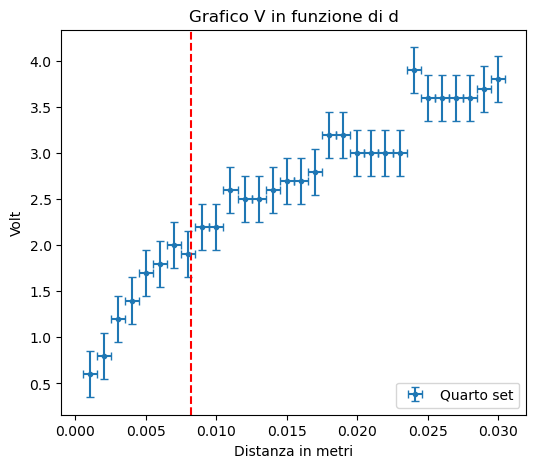

In [8]:
df = Leggi_File_excel(url, 4)

d = df[Col_1].to_numpy()
V = df[Col_2].to_numpy()

d_4 = d[~np.isnan(d)]
d_4/=100
V_4 = V[~np.isnan(V)]



fig , ax = plt.subplots(figsize = (6,5))

ax.errorbar(d_4,V_4, xerr = Err_d, yerr = Err_V, fmt = ".", capsize = 3,label = "Quarto set")
ax.set_xlabel("Distanza in metri")
ax.set_ylabel("Volt")
ax.legend()
ax.set_title("Grafico V in funzione di d")
ax.axvline(x = Distanza_Teorica, color = "red", linestyle = "--")

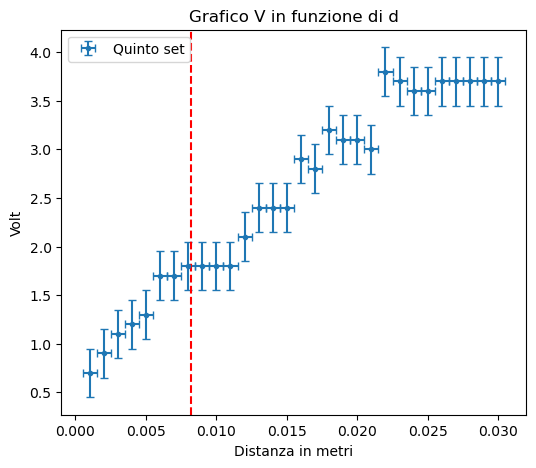

In [9]:
df = Leggi_File_excel(url, 5)

d = df[Col_1].to_numpy()
V = df[Col_2].to_numpy()

d_5 = d[~np.isnan(d)]
d_5/=100
V_5 = V[~np.isnan(V)]



fig , ax = plt.subplots(figsize = (6,5))

ax.errorbar(d_5,V_5, xerr = Err_d, yerr = Err_V, fmt = ".", capsize = 3,label = "Quinto set")
ax.set_xlabel("Distanza in metri")
ax.set_ylabel("Volt")
ax.legend()
ax.set_title("Grafico V in funzione di d")
ax.axvline(x = Distanza_Teorica, color = "red", linestyle = "--")

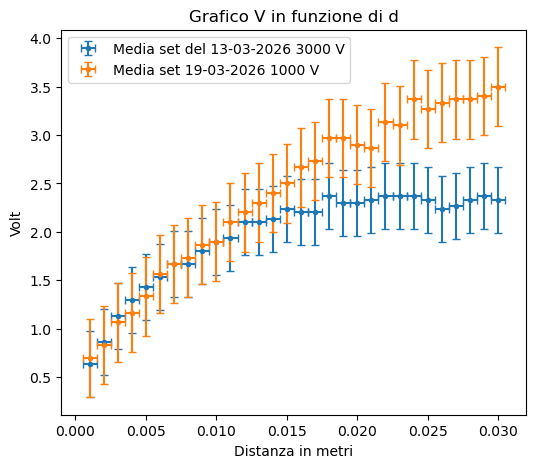

In [10]:
Err_V_0 = Err_V + np.std(V_0)/np.sqrt(V_0.size)
Err_V_1 = Err_V + np.std(V_1)/np.sqrt(V_1.size)
Err_V_2 = Err_V + np.std(V_2)/np.sqrt(V_2.size)
Err_V_3 = Err_V + np.std(V_3)/np.sqrt(V_3.size)
Err_V_4 = Err_V + np.std(V_4)/np.sqrt(V_4.size)
Err_V_5 = Err_V + np.std(V_5)/np.sqrt(V_5.size)



V_3000_mean = V_0 + V_1 + V_2
V_3000_mean /= 3
Errore_V_3000_mean = Err_V_0 + Err_V_1 + Err_V_2
Errore_V_3000_mean /= 3 

V_1000_mean = V_3 + V_4 + V_5
V_1000_mean /= 3
Errore_V_1000_mean = Err_V_5 + Err_V_4 + Err_V_3
Errore_V_1000_mean /= 3

fig , ax = plt.subplots(figsize = (6,5))


ax.errorbar(d_0,V_3000_mean, xerr = Err_d, yerr = Errore_V_3000_mean, fmt = ".", capsize = 3,label = "Media set del 13-03-2026 3000 V")
ax.errorbar(d_1,V_1000_mean, xerr = Err_d, yerr = Errore_V_1000_mean, fmt = ".", capsize = 3, label = "Media set 19-03-2026 1000 V")
#ax.errorbar(d_2,V_2, xerr = Err_d, yerr = Err_V, fmt = ".", capsize = 3, label = "Terzo set 13-03-2026 3000 V")
#ax.errorbar(d_3,V_3, xerr = Err_d, yerr = Err_V, fmt = ".", capsize = 3,label = "Primo set 19-03-2026 1000 V")
#ax.errorbar(d_4,V_4, xerr = Err_d, yerr = Err_V, fmt = ".", capsize = 3, label = "Secondo set 19-03-2026 1000 V")
#ax.errorbar(d_5,V_5, xerr = Err_d, yerr = Err_V, fmt = ".", capsize = 3, label = "Terzo set 19-03-2026 1000 V")
ax.set_xlabel("Distanza in metri")
ax.set_ylabel("Volt")
#ax.grid(True)
ax.legend()
ax.set_title("Grafico V in funzione di d")

fig.savefig("Grafici-complessivi.png", dpi = 300, bbox_inches = "tight")

# Tutti i Set a 3000 V

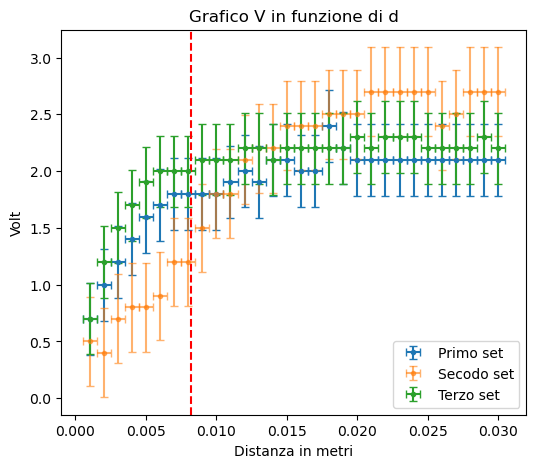

In [11]:
fig , ax = plt.subplots(figsize = (6,5))

ax.errorbar(d_0,V_0, xerr = Err_d, yerr = Err_V_0, fmt = ".", capsize = 3,label = "Primo set")
ax.errorbar(d_1,V_1, xerr = Err_d, yerr = Err_V_1, fmt = ".", capsize = 3, label = "Secodo set", alpha = 0.6)
ax.errorbar(d_2,V_2, xerr = Err_d, yerr = Err_V_2, fmt = ".", capsize = 3, label = "Terzo set")
ax.set_xlabel("Distanza in metri")
ax.set_ylabel("Volt")
#ax.grid(True)
ax.legend()
ax.set_title("Grafico V in funzione di d")
ax.axvline(x = Distanza_Teorica, color = "red", linestyle = "--")

fig.savefig("Grafico-del-16-03-2026 3000 V", dpi = 300, bbox_inches = "tight")

# Tutti i Set a 1000 V

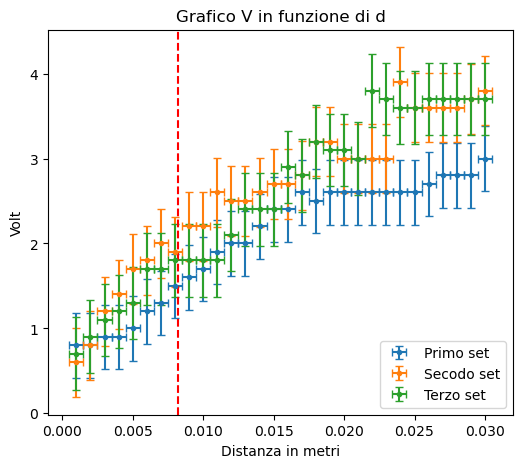

In [12]:
fig , ax = plt.subplots(figsize = (6,5))

ax.errorbar(d_3,V_3, xerr = Err_d, yerr = Err_V_3, fmt = ".", capsize = 3,label = "Primo set")
ax.errorbar(d_4,V_4, xerr = Err_d, yerr = Err_V_4, fmt = ".", capsize = 3, label = "Secodo set")
ax.errorbar(d_5,V_5, xerr = Err_d, yerr = Err_V_5, fmt = ".", capsize = 3, label = "Terzo set")
ax.set_xlabel("Distanza in metri")
ax.set_ylabel("Volt")
#ax.grid(True)
ax.legend()
ax.set_title("Grafico V in funzione di d")
ax.axvline(x = Distanza_Teorica, color = "red", linestyle = "--")
fig.savefig("Grafico-del-19-03-2026 1000V", dpi = 300, bbox_inches = "tight")

# Analisi Dei Dati

In [13]:
# Unità di misura: V, m e C
V0 = 3000

C_sph = 4 * np.pi *epsilon_0 * R_sph**2

Err_C_sph = 4* np.pi * epsilon_0 * R_sph

Q_sph = C_sph * V0
Errore_Q_sph = np.sqrt((2*Err_R_sph/R_sph)**2 + (Err_V/3000)**2) * Q_sph

Q_cond_t = Q_sph *(R_cond/(2*R_sph))**2
Errore_Q_cond_t = (np.abs(Errore_Q_sph/Q_sph) + np.abs(np.sqrt(2)* Errore_Raggio_Cond/R_cond)) * Q_cond_t

# Per la stima della carica che si trova sul condensatore considero i tratti in cui il condesatore restituisce un potenziale costante

V_0_const = V_0[5:]
V_1_const = V_1[15:]
V_2_const = V_2[5:]

#print(V_0_const)

V_0_mean = np.mean(V_0_const)
V_1_mean = np.mean(V_1_const)
V_2_mean = np.mean(V_2_const)

std_V_0 = np.std(V_0_const)
Err_V_0 = Err_V + std_V_0/np.sqrt(V_0_const.size)

std_V_1 = np.std(V_1_const)
Err_V_1 = Err_V + std_V_1/np.sqrt(V_1_const.size)

std_V_2 = np.std(V_2_const)
Err_V_2 = Err_V + std_V_2/np.sqrt(V_2_const.size)


print(f"V0 : {V_0_mean} ± {Err_V_0: .3e}\nV1 : {V_1_mean: .3e} ± {Err_V_1: .3e}\nV2 : {V_2_mean} ± {Err_V_2: .3e}")

"""Per la stima della carica ora moltiplico la tensione media per la capacità del condensatore, ma ricordiamo che
in questo tratto la capacità del condensatore diventa trascurabile rispetto a quella interna dell'eletrometro, 
quindi la nostra stima si baserà sulla quantità
di carica che si trova sul condesatore dell'eletrometro"""

Q_cond_0 = V_0_mean * 27e-12
Err_Q_cond_0 = Err_V_0 * 27e-12

Q_cond_1 = V_1_mean * 27e-12
Err_Q_cond_1 = Err_V_1 * 27e-12

Q_cond_2 = V_2_mean * 27e-12
Err_Q_cond_2 = Err_V_2 * 27e-12

print(f"Q_T: {Q_cond_t: .3e} ± {Errore_Q_cond_t: .3e}")
print(f"Q_0: {Q_cond_0: .3e} ± {Err_Q_cond_0: .3e}")
print(f"Q_1: {Q_cond_1: .3e} ± {Err_Q_cond_1: .3e}")
print(f"Q_2: {Q_cond_2: .3e} ± {Err_Q_cond_2: .3e}")

V0 : 2.024 ±  2.806e-01
V1 :  2.587e+00 ±  2.825e-01
V2 : 2.18 ±  2.679e-01
Q_T:  6.644e-10 ±  1.213e-11
Q_0:  5.465e-11 ±  7.576e-12
Q_1:  6.984e-11 ±  7.627e-12
Q_2:  5.886e-11 ±  7.233e-12


In [14]:
del(d)

# Stima di Q a partire dal grafico del secondo punto

In [15]:
df = Leggi_File_excel(url, 6)

Col_1 = "V"
Col_2 = "n"

d = 5e-3

C_cond = epsilon_0 * Area_Condensatore
C_cond/=d

C_equivalente = C_cond + 27e-12

V = df[Col_1].to_numpy()
n = df[Col_2].to_numpy()

V_N_1 = V[~np.isnan(V)]
n_N_1 = n[~np.isnan(n)]

df.head()

,n,V
0,1,8
1,2,16
2,3,24
3,4,34
4,5,42


In [16]:
df = Leggi_File_excel(url, 7)

d = 5e-3

C_cond = epsilon_0 * Area_Condensatore
C_cond/=d

C_equivalente = C_cond + 27e-12

Col_1 = "V"
Col_2 = "n"

V = df[Col_1].to_numpy()
n = df[Col_2].to_numpy()

V_N_2 = V[~np.isnan(V)]
n_N_2 = n[~np.isnan(n)]


In [17]:
df = Leggi_File_excel(url, 8)

d = 5e-3

C_cond = epsilon_0 * Area_Condensatore
C_cond/=d



Col_1 = "V"
Col_2 = "n"

V = df[Col_1].to_numpy()
n = df[Col_2].to_numpy()

V_N_3 = V[~np.isnan(V)]
n_N_3 = n[~np.isnan(n)]


In [18]:
std_V_N_1 = np.std(V_N_1)
Err_V_N_1 = Err_V + std_V_N_1/np.sqrt(V_N_3.size)
std_V_N_2 = np.std(V_N_2)
Err_V_N_2 = Err_V + std_V_N_2/np.sqrt(V_N_2.size)
std_V_N_3 = np.std(V_N_3)
Err_V_N_3 = Err_V + std_V_N_3/np.sqrt(V_N_3.size)


Errore_Capacita_Condensatore = np.sqrt((Errore_Area_Condensatore/Area_Condensatore)**2 + (Err_d/d)**2) * C_cond

In [19]:
V_N_mean = V_N_1 + V_N_2 + V_N_3
V_N_mean = V_N_mean/3

Errore_V_N_mean = Err_V_N_3 + Err_V_N_2 + Err_V_N_1
Errore_V_N_mean = Errore_V_N_mean/3

x = np.linspace(0, 10, 100)

"""Retta Massima Pendenza"""
m_max = (V_N_1[-1] + Err_V_N_1) - (0 - Err_V_N_1)
m_max /= x[-1] - 0
"""Retta Minima Pendenza"""

m_min = (V_N_1[-1] - Err_V_N_1) - (0 + Err_V_N_1)
m_min /= x[-1] - 0

""" Stina di q max e min """
y_fit_1 =  Linear_Fit(m_max, 0, x)
y_fit_2 =  Linear_Fit(m_min, 0, x)
q_max = (V_N_1[-1] + Err_V_N_1) - y_fit_1[-1]  
q_min = (V_N_1[-1] - Err_V_N_1) - y_fit_2[-1]  

""" Correggo i fit del fattore q_max q_min """
y_fit_1 = y_fit_1 + q_max 
y_fit_2 = y_fit_2 + q_min

""" Ricavo i valori best e i rispettivi errori """
m_best_1 = m_max + m_min
m_best_1 /= 2

Errore_m_best_1 = m_max - m_min
Errore_m_best_1 /= 2

q_best_1 = q_max + q_min
q_best_1 /= 2

Errore_q_best_1 = np.abs(q_max - q_min)
Errore_q_best_1 /= 2

y_fit_3 =  Linear_Fit(m_best_1, q_best_1, x)

print(f"q_best: {q_best_1} ± {Errore_q_best_1}")

print(f"m_best: {m_best_1} ± {Errore_m_best_1}")
#print(y_fit_1)

Q_prova = V_N_1[0] * C_equivalente
print(Q_prova)
Carica_1 = m_best_1 * (C_equivalente)
Errore_Carica_1 = np.sqrt((Errore_m_best_1/m_best_1)**2 + (Errore_Capacita_Condensatore/C_equivalente)**2 ) * Carica_1
print(f"Q_1: {Carica_1: .3e} ± {Errore_Carica_1: .3e}")

q_best: 0.0 ± 7.83188630882843
m_best: 8.3 ± 1.5663772617656861
5.703560690253668e-10
Q_1:  5.917e-10 ±  1.176e-10


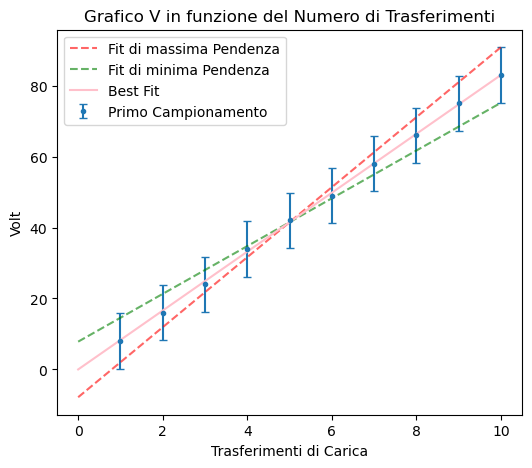

In [20]:


fig , ax = plt.subplots(figsize = (6,5))


ax.errorbar(n_N_1,V_N_1, yerr = Err_V_N_1, fmt = ".", capsize = 3,label = "Primo Campionamento")
#ax.errorbar(n_N_2,V_N_2, yerr = Err_V_N_2, fmt = ".", capsize = 3, label = "Secodo Campionamento")
#ax.errorbar(n_N_3,V_N_3, yerr = Err_V_N_3, fmt = ".", capsize = 3, label = "Terzo Campionamento")
ax.plot(x, y_fit_1, color = "red", label = "Fit di massima Pendenza",linestyle = "--", alpha = 0.6)
ax.plot(x, y_fit_2, color = "green", label = "Fit di minima Pendenza",linestyle = "--", alpha = 0.6)
ax.plot(x, y_fit_3, color = "pink", label = "Best Fit")
ax.set_xlabel("Trasferimenti di Carica")
ax.set_ylabel("Volt")
#ax.grid(True)
ax.legend()
ax.set_title("Grafico V in funzione del Numero di Trasferimenti")
fig.savefig("Grafico V in funzione del Numero di Trasferimenti(1).png", dpi = 300 , bbox_inches = "tight")

In [21]:
x = np.linspace(0, 10, 100)

"""Retta Massima Pendenza"""
m_max = (V_N_2[-1] + Err_V_N_2) - (0 - Err_V_N_2)
m_max /= x[-1] - 0
"""Retta Minima Pendenza"""

m_min = (V_N_2[-1] - Err_V_N_2) - (0 + Err_V_N_2)
m_min /= x[-1] - 0

""" Stina di q max e min """
y_fit_1 =  Linear_Fit(m_max, 0, x)
y_fit_2 =  Linear_Fit(m_min, 0, x)
q_max = (V_N_2[-1] + Err_V_N_2) - y_fit_1[-1]  
q_min = (V_N_2[-1] - Err_V_N_2) - y_fit_2[-1]  

""" Correggo i fit del fattore q_max q_min """
y_fit_1 = y_fit_1 + q_max 
y_fit_2 = y_fit_2 + q_min

""" Ricavo i valori best e i rispettivi errori """
m_best_2 = m_max + m_min
m_best_2 /= 2

Errore_m_best_2 = m_max - m_min
Errore_m_best_2 /= 2

q_best_2 = q_max + q_min
q_best_2 /= 2

Errore_q_best_2 = np.abs(q_max - q_min)
Errore_q_best_2 /= 2

y_fit_3 =  Linear_Fit(m_best_2, q_best_2, x)

print(f"q_best: {q_best_2} ± {Errore_q_best_2}")

print(f"m_best: {m_best_2} ± {Errore_m_best_2}")
#print(y_fit_1)

Q_prova = V_N_2[0] * C_equivalente
print(Q_prova)
Carica_2 = m_best_2 * (C_equivalente)
Errore_Carica_2 = np.sqrt((Errore_m_best_2/m_best_2)**2 + (Errore_Capacita_Condensatore/C_equivalente)**2 ) * Carica_2
print(f"Q_2: {Carica_2: .3e} ± {Errore_Carica_2: .3e}")

q_best: 0.0 ± 7.8149851288684005
m_best: 8.600000000000001 ± 1.5629970257736803
7.842395949098794e-10
Q_2:  6.131e-10 ±  1.178e-10


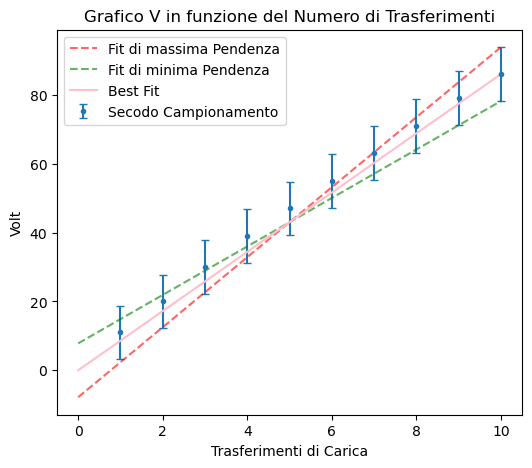

In [22]:
fig , ax = plt.subplots(figsize = (6,5))


#ax.errorbar(n_N_1,V_N_1, yerr = Err_V_N_1, fmt = ".", capsize = 3,label = "Primo Campionamento", alpha = 0.6)
ax.errorbar(n_N_2,V_N_2, yerr = Err_V_N_2, fmt = ".", capsize = 3, label = "Secodo Campionamento")
#ax.errorbar(n_N_3,V_N_3, yerr = Err_V_N_3, fmt = ".", capsize = 3, label = "Terzo Campionamento")
ax.plot(x, y_fit_1, color = "red", label = "Fit di massima Pendenza",linestyle = "--", alpha = 0.6)
ax.plot(x, y_fit_2, color = "green", label = "Fit di minima Pendenza",linestyle = "--", alpha = 0.6)
ax.plot(x, y_fit_3, color = "pink", label = "Best Fit")
ax.set_xlabel("Trasferimenti di Carica")
ax.set_ylabel("Volt")
#ax.grid(True)
ax.legend()
ax.set_title("Grafico V in funzione del Numero di Trasferimenti")

fig.savefig("Grafico V in funzione del Numero di Trasferimenti(2).png", dpi = 300 , bbox_inches = "tight")

In [23]:
x = np.linspace(0, 10, 100)

"""Retta Massima Pendenza"""
m_max = (V_N_3[-1] + Err_V_N_3) - (0 - Err_V_N_3)
m_max /= x[-1] - 0
"""Retta Minima Pendenza"""

m_min = (V_N_3[-1] - Err_V_N_3) - (0 + Err_V_N_3)
m_min /= x[-1] - 0

""" Stina di q max e min """
y_fit_1 =  Linear_Fit(m_max, 0, x)
y_fit_2 =  Linear_Fit(m_min, 0, x)
q_max = (V_N_3[-1] + Err_V_N_3) - y_fit_1[-1]  
q_min = (V_N_3[-1] - Err_V_N_3) - y_fit_2[-1]  

""" Correggo i fit del fattore q_max q_min """
y_fit_1 = y_fit_1 + q_max 
y_fit_2 = y_fit_2 + q_min

""" Ricavo i valori best e i rispettivi errori """
m_best_3 = m_max + m_min
m_best_3 /= 2

Errore_m_best_3 = m_max - m_min
Errore_m_best_3 /= 2

q_best_3 = q_max + q_min
q_best_3 /= 2

Errore_q_best_3 = np.abs(q_max - q_min)
Errore_q_best_3 /= 2

y_fit_3 =  Linear_Fit(m_best_3, q_best_3, x)

print(f"q_best: {q_best_3} ± {Errore_q_best_3}")

print(f"m_best: {m_best_3} ± {Errore_m_best_3}")
#print(y_fit_1)

Q_prova = V_N_3[0] * C_equivalente
print(Q_prova)
Carica_3 = m_best_3 * (C_equivalente)
Errore_Carica_3 = np.sqrt((Errore_m_best_3/m_best_3)**2 + (Errore_Capacita_Condensatore/C_equivalente)**2 ) * Carica_3
print(f"Q_3: {Carica_3: .3e} ± {Errore_Carica_3: .3e}")

q_best: 0.0 ± 8.093723605533285
m_best: 8.9 ± 1.618744721106657
7.129450862817085e-10
Q_3:  6.345e-10 ±  1.220e-10


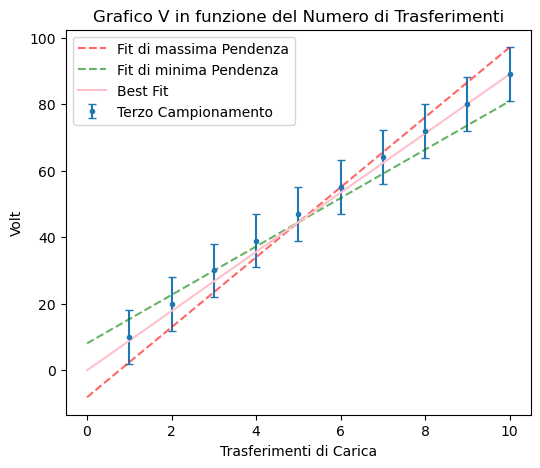

In [24]:
fig , ax = plt.subplots(figsize = (6,5))


#ax.errorbar(n_N_1,V_N_1, yerr = Err_V_N_1, fmt = ".", capsize = 3,label = "Primo Campionamento", alpha = 0.6)
#ax.errorbar(n_N_2,V_N_2, yerr = Err_V_N_2, fmt = ".", capsize = 3, label = "Secodo Campionamento")
ax.errorbar(n_N_3,V_N_3, yerr = Err_V_N_3, fmt = ".", capsize = 3, label = "Terzo Campionamento")
ax.plot(x, y_fit_1, color = "red", label = "Fit di massima Pendenza", linestyle = "--", alpha = 0.6)
ax.plot(x, y_fit_2, color = "green", label = "Fit di minima Pendenza",linestyle = "--", alpha = 0.6)
ax.plot(x, y_fit_3, color = "pink", label = "Best Fit")
ax.set_xlabel("Trasferimenti di Carica")
ax.set_ylabel("Volt")
#ax.grid(True)
ax.legend()
ax.set_title("Grafico V in funzione del Numero di Trasferimenti")
fig.savefig("Grafico V in funzione del Numero di Trasferimenti(3).png", dpi = 300 , bbox_inches = "tight")

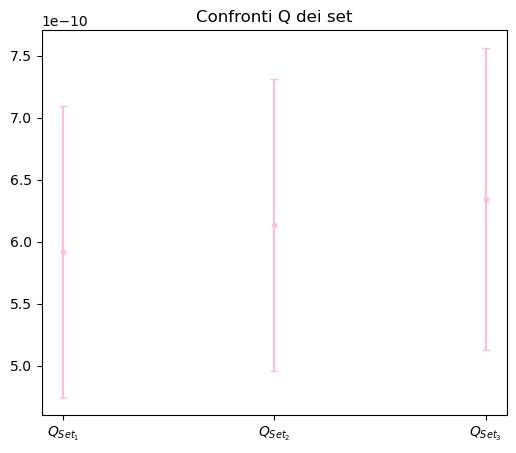

In [25]:
Nomi = [r'$Q_{Set_1}$', r'$Q_{Set_2}$', r'$Q_{Set_3}$']
Cariche = [Carica_1, Carica_2, Carica_3]
Errore_Cariche = [Errore_Carica_1, Errore_Carica_2, Errore_Carica_3]
fig , ax = plt.subplots(figsize = (6,5))

ax.errorbar(Nomi, Cariche, fmt = '.', yerr = Errore_Cariche, capsize = 3, color = "pink")
ax.set_title("Confronti Q dei set")
fig.savefig("Grafico Confronti Q nei tre set.png", dpi = 300 , bbox_inches = "tight")

# Condensatore fisso a 3000 V  al variare di d (Dichiaro le dimensioni della gabbia di faraday)

In [26]:
df = Leggi_File_excel(url, 10)


Col_1 = "d(cm)2"

Col_2 = "V2"

d = df[Col_1].to_numpy()
V = df[Col_2].to_numpy()

d_6 = d[~np.isnan(d)]
d_6/=100
V_6 = V[~np.isnan(V)]



"""Raggi in mm e altezze in cm"""

R_int_f = 9.85/2
R_ext_f = 14.34/2
h_int_f = 15.2
h_ext_f = 19

"""Converto tutto in metri"""

h_ext_f *= 1e-2
h_int_f *= 1e-2

R_int_f *= 1e-2
R_ext_f *= 1e-2



"""Errori Delle Misure Sopra Citate"""
"""Gli errori delle h sono le stesse
Idem per gli errori dei raggi"""
Err_h = 5e-4
Err_r_f = 5e-5

"""Area è la variabile che contiene l'area del condensatore"""

Q_cond_T_6 = epsilon_0 * Area_Condensatore * V0

Q_cond_T_6 /= d_6

"""Q_cond è un vettore che presenta Q al variare di d"""

"""Stimo pure L'errore della capacita' sulla gabbia di faraday"""
C_f = 2*np.pi*h_int_f*epsilon_0
C_f/= np.log(R_ext_f/R_int_f)

Err_C_f = 2 * np.pi * epsilon_0 * np.sqrt(Err_h**2 + 2* h_int_f**2 * (R_int_f/R_ext_f)**2 * (np.log(R_int_f/R_ext_f))**2 * Err_r_f**2)
Err_C_f /= np.log(R_ext_f/R_int_f) 


#V_6_mean = np.mean(V_6)

Q_f_s_6 = V_6*(C_f + 27e-12)


Q_f_s_6_mean = V_6_mean*(C_f + 27e-12)



print(F"Capacita' di faraday: {C_f} ± {Err_C_f}")
#print(Q_f_s_6_mean)

NameError: name 'V_6_mean' is not defined

In [ ]:
df = Leggi_File_excel(url, 11)


Col_1 = "d (cm)"

Col_2 = "V"

d = df[Col_1].to_numpy()
V = df[Col_2].to_numpy()

d_7 = d[~np.isnan(d)]
d_7/=100
V_7 = V[~np.isnan(V)]


Q_cond_T_7 = epsilon_0 * Area_Condensatore * V0

Q_cond_T_7 /= d_7

V_7_mean = np.mean(V_7)

Q_f_s_7 = V_7*(C_f + 27e-12)


Q_f_s_7_mean = V_7_mean*(C_f + 27e-12)


print(C_f)
#print(Q_f_s_7_mean)

In [ ]:
df = Leggi_File_excel(url, 12)


Col_1 = "d (cm)"

Col_2 = "V"

d = df[Col_1].to_numpy()
V = df[Col_2].to_numpy()

d_8 = d[~np.isnan(d)]
d_8/=100
V_8 = V[~np.isnan(V)]


Q_cond_T_8 = epsilon_0 * Area_Condensatore * V0

Q_cond_T_8 /= d_8


V_8_mean = np.mean(V_8)

Q_f_s_8 = V_8*(C_f + 27e-12)


Q_f_s_8_mean = V_8_mean*(C_f + 27e-12)


print(C_f)
#print(Q_f_s_8_mean)

# Stima di Q di faraday troncando i valori

In [ ]:
np.sort(V_6)
V_6_cut = V_6[16::]
V_7_cut = V_7[7::]
V_8_cut = V_8[7::]

Err_V_6_cut = Err_V + np.std(V_6_cut)/np.sqrt(V_6_cut.size)
Err_V_7_cut = Err_V + np.std(V_7_cut)/np.sqrt(V_7_cut.size)
Err_V_8_cut = Err_V + np.std(V_8_cut)/np.sqrt(V_8_cut.size)

print(f"V_6 Troncato: {V_6_cut}\nV_7 Troncato: {V_7_cut}\nV_8 Troncato: {V_8_cut}")

V_6_cut_mean = np.mean(V_6_cut)
V_7_cut_mean = np.mean(V_7_cut)
V_8_cut_mean = np.mean(V_8_cut)

Q_f_s_6_cut_mean = V_6_cut_mean*(C_f + 27e-12)
Q_f_s_7_cut_mean = V_7_cut_mean*(C_f + 27e-12)
Q_f_s_8_cut_mean = V_8_cut_mean*(C_f + 27e-12)

Errore_Q_f_s_6_cut = np.sqrt((Err_V_6_cut/V_6_cut_mean)**2 + (Err_C_f/C_f)**2) * Q_f_s_6_cut_mean
Errore_Q_f_s_7_cut = np.sqrt((Err_V_7_cut/V_7_cut_mean)**2 + (Err_C_f/C_f)**2) * Q_f_s_7_cut_mean
Errore_Q_f_s_8_cut = np.sqrt((Err_V_8_cut/V_8_cut_mean)**2 + (Err_C_f/C_f)**2) * Q_f_s_8_cut_mean

print(f"Q_6: {Q_f_s_6_cut_mean: .3e} ± {Errore_Q_f_s_6_cut: .3e}\nQ_7: {Q_f_s_7_cut_mean: .3e} ± {Errore_Q_f_s_7_cut: .3e}\nQ_8: {Q_f_s_8_cut_mean: .3e} ± {Errore_Q_f_s_8_cut: .3e}")


# Stima Del Q Teorico 

In [ ]:
x = np.linspace(0.0005, 0.1, 100)
Q_teorico =  Voltage_Fit(Area_Condensatore, 3000, x , epsilon_0)

In [ ]:
Err_V_6 = Err_V + np.std(V_6)/np.sqrt(V_6.size)
Err_V_7 = Err_V + np.std(V_7)/np.sqrt(V_7.size)
Err_V_8 = Err_V + np.std(V_8)/np.sqrt(V_8.size)

V_6_mean = np.mean(V_6)
V_7_mean = np.mean(V_7)
V_8_mean = np.mean(V_8)

Errore_Q_f_s_6 = np.sqrt((Err_V_6/V_6_mean)**2 + (Err_C_f/C_f)**2) * Q_f_s_6_mean
Errore_Q_f_s_7 = np.sqrt((Err_V_7/V_7_mean)**2 + (Err_C_f/C_f)**2) * Q_f_s_7_mean
Errore_Q_f_s_8 = np.sqrt((Err_V_8/V_8_mean)**2 + (Err_C_f/C_f)**2) * Q_f_s_8_mean

"""Stimo l'errore sulla capacita' del condensatore"""

Errore_Q_cond_t_8 = np.sqrt((Errore_Area_Condensatore/Area_Condensatore)**2 + (Err_C_f/C_f)**2) * Q_f_s_8_mean

# Errori Dei V del Terzo punto e delle rispettive cariche (Nome Variabili: "Err_V_numero set") Stimo anche l'errore sulla carica Sperimentale

In [ ]:

fig , ax = plt.subplots(figsize = (6,5))


ax.errorbar(d_6,V_6, yerr = Err_V + np.std(V_6)/np.sqrt(V_6.size), fmt = ".", capsize = 3,label = "Primo Campionamento", alpha = 0.6)
ax.errorbar(d_7,V_7, yerr = Err_V + np.std(V_7)/np.sqrt(V_7.size), fmt = ".", capsize = 3, label = "Secodo Campionamento")
#ax.plot(range(0,100),y_fit_2, label = "Fit del secondo Campionamento")
ax.errorbar(d_8,V_8, yerr = Err_V + np.std(V_8)/np.sqrt(V_8.size), fmt = ".", capsize = 3, label = "Terzo Campionamento")
ax.axvline(x = Distanza_Teorica, color = "red", linestyle = "--")
ax.set_xlabel("Distanza (m)")
ax.set_ylabel("Volt")
#ax.grid(True)
ax.legend()
ax.set_title("Grafico V in funzione della distanza")

fig.savefig("Grafico Faraday V in funzione della Distanza.png", dpi = 300, bbox_inches = "tight")

In [ ]:
fig , ax = plt.subplots(figsize = (6,5))


ax.errorbar(d_6,Q_cond_T_6, yerr = 0, fmt = ".", capsize = 3,label = "Primo Campionamento", alpha = 0.6)
ax.errorbar(d_7,Q_cond_T_7, yerr = 0, fmt = ".", capsize = 3, label = "Secodo Campionamento")
#ax.plot(range(0,100),y_fit_2, label = "Fit del secondo Campionamento")
ax.errorbar(d_8,Q_cond_T_8, yerr = 0, fmt = ".", capsize = 3, label = "Terzo Campionamento")
ax.plot(x , Q_teorico, linestyle = "--", color = "black", label = "Carica Teorica")

ax.set_xlabel("Distanza(m)")
ax.set_ylabel("Q(C)")
#ax.grid(True)
ax.legend()
ax.set_title("Carica del condensatore al variare della Distanza(Teoricamente)")

In [ ]:


fig , ax = plt.subplots(figsize = (6,5))


ax.errorbar(d_6,Q_f_s_6, yerr = Errore_Q_f_s_6, fmt = ".", capsize = 3,label = "Primo Campionamento", alpha = 0.6)
ax.errorbar(d_7,Q_f_s_7, yerr = Errore_Q_f_s_7, fmt = ".", capsize = 3, label = "Secodo Campionamento")
#ax.plot(range(0,100),y_fit_2, label = "Fit del secondo Campionamento")
ax.errorbar(d_8,Q_f_s_8, yerr = Errore_Q_f_s_8, fmt = ".", capsize = 3, label = "Terzo Campionamento")
ax.axvline(x = Distanza_Teorica, color = "red", linestyle = "--")
ax.set_xlabel("Distanza(m)")
ax.set_ylabel("Q(C)")
#ax.grid(True)
ax.legend()
ax.set_title("Carica del condensatore al variare della Distanza(Sperimentalmente)")
fig.savefig("Grafico Faraday Q in funzione della Distanza.png", dpi = 300, bbox_inches = "tight")

In [ ]:
""""np.sort(V_6)
V_6_cut = V_6[16::]
V_7_cut = V_7[7::]
V_8_cut = V_8[7::]

Err_V_6_cut = Err_V + np.std(V_6_cut)/np.sqrt(V_6_cut.size)
Err_V_7_cut = Err_V + np.std(V_7_cut)/np.sqrt(V_7_cut.size)
Err_V_8_cut = Err_V + np.std(V_8_cut)/np.sqrt(V_8_cut.size)

print(f"V_6 Troncato: {V_6_cut}\nV_7 Troncato: {V_7_cut}\nV_8 Troncato: {V_8_cut}")

V_6_cut_mean = np.mean(V_6_cut)
V_7_cut_mean = np.mean(V_7_cut)
V_8_cut_mean = np.mean(V_8_cut)

Q_f_s_6_cut_mean = V_6_cut_mean*(C_f + 27e-12)
Q_f_s_7_cut_mean = V_7_cut_mean*(C_f + 27e-12)
Q_f_s_8_cut_mean = V_8_cut_mean*(C_f + 27e-12)

Errore_Q_f_s_6_cut = np.sqrt((Err_V_6_cut/V_6_cut_mean)**2 + (Err_C_f/C_f)**2) * Q_f_s_6_cut_mean
Errore_Q_f_s_7_cut = np.sqrt((Err_V_7_cut/V_7_cut_mean)**2 + (Err_C_f/C_f)**2) * Q_f_s_7_cut_mean
Errore_Q_f_s_8_cut = np.sqrt((Err_V_8_cut/V_8_cut_mean)**2 + (Err_C_f/C_f)**2) * Q_f_s_8_cut_mean

print(f"Q_6: {Q_f_s_6_cut_mean: .3e} ± {Errore_Q_f_s_6_cut: .3e}\nQ_7: {Q_f_s_7_cut_mean: .3e} ± {Errore_Q_f_s_7_cut: .3e}\nQ_8: {Q_f_s_8_cut_mean: .3e} ± {Errore_Q_f_s_8_cut: .3e}")
"""

In [ ]:
Nomi = [r'$Q_{set_1}$',r'$Q_{set_2}$',r'$Q_{set_3}$']
Q_Faraday = [Q_f_s_6_cut_mean, Q_f_s_7_cut_mean, Q_f_s_8_cut_mean]
Errori_Q_Faraday = [Errore_Q_f_s_6_cut, Errore_Q_f_s_7_cut, Errore_Q_f_s_8_cut]
fig, ax = plt.subplots(figsize = (6,5))

ax.errorbar(Nomi, Q_Faraday, fmt = '.', yerr =Errori_Q_Faraday, capsize = 3 )
ax.set_title(r'Confronto tra le Q stimate nei set')
ax.set_ylabel(r'Carica $(C)$')

fig.savefig("Grafico Faraday Confronto Cariche dei set.png", dpi = 300, bbox_inches = "tight")

In [ ]:
df = Leggi_File_excel(url, 13)

d = df[Col_1].to_numpy()
V = df[Col_2].to_numpy()

d_9 = d[~np.isnan(d)]
d_9/=100
V_9 = V[~np.isnan(V)]


Err_V_7 = Err_V + np.std(V_9)/np.sqrt(V_9.size)


fig , ax = plt.subplots(figsize = (6,5))

ax.errorbar(d_9,V_9, xerr = Err_d, yerr = Err_V_7, fmt = ".", capsize = 3,label = "Set Senza Dielettrico")
ax.set_xlabel("Distanza in metri")
ax.set_ylabel("Volt")
ax.legend()
ax.set_title("Grafico V in funzione di d")

In [ ]:
df = Leggi_File_excel(url, 14)

d = df[Col_1].to_numpy()
V = df[Col_2].to_numpy()

d_10 = d[~np.isnan(d)]
d_10/=100
V_10 = V[~np.isnan(V)]


Err_V_10 = Err_V + np.std(V_10)/np.sqrt(V_10.size)

fig , ax = plt.subplots(figsize = (6,5))

ax.errorbar(d_10,V_10, xerr = Err_d, yerr = Err_V_10, fmt = ".", capsize = 3,label = "Set Con il dielettrico")
ax.set_xlabel("Distanza in metri")
ax.set_ylabel("Volt")
ax.legend()
ax.set_title("Grafico V in funzione di d")

In [ ]:
fig , ax = plt.subplots(figsize = (6,5))

ax.errorbar(d_10,V_10, xerr = Err_d, yerr = Err_V_10, fmt = ".", capsize = 3,label = "Set Con il dielettrico")
ax.errorbar(d_9,V_9, xerr = Err_d, yerr = Err_V_10, fmt = ".", capsize = 3,label = "Set senza il dielettrico")
ax.set_xlabel("Distanza in metri")
ax.set_ylabel("Volt")
ax.axvline(x = Distanza_Teorica, color = "red", linestyle = "--", label = "Distanza Teorica senza dieletrico", alpha = 0.6)
ax.legend()
ax.set_title("Grafico confronto Tensioni del Quarto punto")
fig.savefig("Grafico confronti Tensioni del Quarto punto.png", dpi = 300, bbox_inches = "tight")